# Smart City Traffic & Urban Mobility Intelligence
## Fully detailed exploratory data analysis (EDA) and intersection segmentation

**Scope.** This notebook performs descriptive and diagnostic analysis only—no supervised prediction or target modeling. The clustering section is unsupervised segmentation requested for operational planning, not a predictive model.

**Dataset.** 204,000 hourly sensor records from 100 intersections across a fictional smart metropolis. The supplied description credits **Mobeen Fatima** as the dataset author.

**Questions answered**

1. Is the sensor panel complete, unique, and internally plausible?
2. When and where do demand, delay, congestion, and emissions concentrate?
3. How do weather, incidents, road design, and signal settings relate to outcomes?
4. Which intersections share similar operating profiles?
5. Which findings translate into practical monitoring or intervention priorities?

> Interpretation guardrail: this is simulated observational data. Differences are associations, not causal effects.

## 0. Reproducibility and package setup

The notebook prefers Polars for fast ingestion, then converts to pandas for broad plotting and statistical-library compatibility. If needed, install dependencies once with:

```python
%pip install pandas polars seaborn matplotlib phik scikit-learn scipy statsmodels
```

In [1]:
import os
from pathlib import Path
import warnings

# Writable caches prevent font/cache warnings in restricted notebook environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / ".cache"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sea
import matplotlib.pyplot as plt
import phik  # registers pandas' .phik_matrix accessor

from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sea.set_theme(style="whitegrid", context="notebook")
COLORS = ["#2563EB", "#0F766E", "#F59E0B", "#DC2626", "#7C3AED", "#64748B"]
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})

DATA_CANDIDATES = [
    Path("work/smart_city_traffic_mobility.csv"),
    Path("/Users/khoatran3126/Downloads/smart_city_traffic_mobility.csv"),
    Path("smart_city_traffic_mobility.csv"),
    Path("../smart_city_traffic_mobility.csv"),
    Path("/content/smart_city_traffic_mobility.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Update DATA_CANDIDATES so one entry points to smart_city_traffic_mobility.csv")

print(f"Using: {DATA_PATH}")

Using: /Users/khoatran3126/Downloads/smart_city_traffic_mobility.csv


## 1. Load the data and assign analytical roles

The dataset is a **panel time series**: each timestamp should contain one record per intersection. IDs and coordinates are retained for integrity and spatial analysis but excluded from correlation calculations where they have no numeric meaning.

In [2]:
# Polars parses the 47-column CSV efficiently. The pandas conversion supports Seaborn and Phi-K.
pl_df = pl.read_csv(DATA_PATH, try_parse_dates=True, infer_schema_length=10_000)
df = pl_df.to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="raise")
df = df.sort_values(["timestamp", "intersection_id"]).reset_index(drop=True)

identifier_cols = ["record_id", "road_id", "intersection_id"]
categorical_cols = df.select_dtypes(include="object").columns.difference(identifier_cols).tolist()
binary_cols = [c for c in df.columns if df[c].dropna().nunique() == 2 and pd.api.types.is_numeric_dtype(df[c])]
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
continuous_cols = [c for c in numeric_cols if c not in binary_cols + ["hour", "day_of_week"]]

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum()/1024**2:,.1f} MB")
display(df.head(3))

Shape: 204,000 rows × 47 columns
Memory: 167.6 MB


,record_id,city_zone,road_id,intersection_id,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,average_speed,heavy_vehicle_count,motorcycle_count,public_transport_count,traffic_density,queue_length,average_wait_time,timestamp,hour,day_of_week,is_weekend,is_holiday,rush_hour,peak_period,temperature,rainfall_mm,visibility_km,air_quality_index,weather_condition,nearby_school,nearby_hospital,nearby_market,construction_activity,road_condition,parking_occupancy,public_event,accident_reported,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate,congestion_level
0,REC_0000001,Financial District,RD_206,INT_001,40.76,-73.99,Local Street,2,40,162,40.00,12,9,7,27.00,14.30,1.60,2026-01-01,0,3,0,0,0,Night,11.10,0.00,10.00,52,Clear,0,0,0,1,Poor,40.50,0,0,1,Optimal,60,18,0,162.00,16.80,39.14,8.53,Low
1,REC_0002041,Industrial East,RD_869,INT_002,40.75,-73.94,Arterial,3,60,184,59.60,13,22,5,20.40,3.80,0.30,2026-01-01,0,3,0,0,0,Night,13.60,0.00,9.50,48,Clear,0,1,1,0,Good,45.90,0,0,2,Optimal,60,18,0,184.00,12.70,43.54,9.29,Low
2,REC_0004081,Financial District,RD_158,INT_003,40.70,-74.08,Arterial,3,60,235,55.40,9,21,11,26.10,12.50,1.20,2026-01-01,0,3,0,0,0,Night,12.50,0.00,8.80,38,Clear,1,0,0,0,Good,45.90,0,0,2,Optimal,60,19,0,235.00,20.00,56.43,12.22,Low


In [3]:
role_summary = pd.DataFrame({
    "role": ["Identifiers", "Categorical", "Binary indicators", "Other numeric", "Timestamp"],
    "count": [len(identifier_cols), len(categorical_cols), len(binary_cols), len(numeric_cols) - len(binary_cols), 1],
    "examples": [
        ", ".join(identifier_cols),
        ", ".join(categorical_cols[:6]),
        ", ".join(binary_cols[:6]),
        ", ".join([c for c in numeric_cols if c not in binary_cols][:6]),
        "timestamp",
    ],
})
display(role_summary)

,role,count,examples
0,Identifiers,3,"record_id, road_id, intersection_id"
1,Categorical,7,"city_zone, congestion_level, iot_sensor_health..."
2,Binary indicators,11,"is_weekend, is_holiday, rush_hour, nearby_scho..."
3,Other numeric,25,"latitude, longitude, lanes, speed_limit, vehic..."
4,Timestamp,1,timestamp


## 2. Panel integrity, coverage, and data quality

A trustworthy traffic panel needs: unique record keys, unique intersection–timestamp pairs, a regular hourly clock, the expected number of intersections per hour, and plausible physical ranges. The checks below are explicit and auditable.

In [4]:
n_intersections = df["intersection_id"].nunique()
timestamps = pd.DatetimeIndex(df["timestamp"].drop_duplicates().sort_values())
expected_clock = pd.date_range(timestamps.min(), timestamps.max(), freq="h")
rows_per_hour = df.groupby("timestamp")["intersection_id"].nunique()
rows_per_intersection = df.groupby("intersection_id")["timestamp"].nunique()

integrity = pd.DataFrame({
    "check": [
        "Unique record_id", "Unique intersection × timestamp", "Hourly timestamps complete",
        "Every hour has all intersections", "Every intersection has all hours"
    ],
    "observed": [
        df["record_id"].is_unique,
        not df.duplicated(["intersection_id", "timestamp"]).any(),
        len(timestamps) == len(expected_clock) and timestamps.equals(expected_clock),
        rows_per_hour.eq(n_intersections).all(),
        rows_per_intersection.eq(len(timestamps)).all(),
    ],
})
integrity["status"] = np.where(integrity["observed"], "PASS", "REVIEW")

coverage = pd.Series({
    "start": timestamps.min(), "end": timestamps.max(), "hours": len(timestamps),
    "intersections": n_intersections, "rows": len(df),
    "expected_rows": len(timestamps) * n_intersections,
}).to_frame("value")
display(coverage, integrity)

,value
start,2026-01-01 00:00:00
end,2026-03-26 23:00:00
hours,2040
intersections,100
rows,204000
expected_rows,204000


,check,observed,status
0,Unique record_id,True,PASS
1,Unique intersection × timestamp,True,PASS
2,Hourly timestamps complete,False,REVIEW
3,Every hour has all intersections,True,PASS
4,Every intersection has all hours,True,PASS


In [5]:
missing = df.isna().sum().rename("missing_rows").to_frame()
missing["missing_pct"] = 100 * missing["missing_rows"] / len(df)
missing = missing.sort_values(["missing_rows", "missing_pct"], ascending=False)

plausibility = pd.DataFrame({
    "rule": [
        "vehicle_count ≥ 0", "average_speed ≥ 0", "average_speed ≤ 1.5 × speed_limit",
        "traffic_density ≥ 0", "queue_length ≥ 0", "average_wait_time ≥ 0",
        "congestion_score within 0–100", "parking_occupancy within 0–100",
        "rainfall_mm ≥ 0", "visibility_km ≥ 0",
    ],
    "violations": [
        (df.vehicle_count < 0).sum(), (df.average_speed < 0).sum(),
        (df.average_speed > 1.5 * df.speed_limit).sum(), (df.traffic_density < 0).sum(),
        (df.queue_length < 0).sum(), (df.average_wait_time < 0).sum(),
        (~df.congestion_score.between(0, 100)).sum(), (~df.parking_occupancy.between(0, 100)).sum(),
        (df.rainfall_mm < 0).sum(), (df.visibility_km < 0).sum(),
    ],
})
plausibility["status"] = np.where(plausibility.violations.eq(0), "PASS", "REVIEW")
display(missing.head(12), plausibility)
print(f"Exact duplicate rows: {df.duplicated().sum():,}")

,missing_rows,missing_pct
record_id,0,0.00
city_zone,0,0.00
road_id,0,0.00
intersection_id,0,0.00
latitude,0,0.00
longitude,0,0.00
road_type,0,0.00
lanes,0,0.00
speed_limit,0,0.00
vehicle_count,0,0.00


,rule,violations,status
0,vehicle_count ≥ 0,0,PASS
1,average_speed ≥ 0,0,PASS
2,average_speed ≤ 1.5 × speed_limit,0,PASS
3,traffic_density ≥ 0,0,PASS
4,queue_length ≥ 0,0,PASS
5,average_wait_time ≥ 0,0,PASS
6,congestion_score within 0–100,0,PASS
7,parking_occupancy within 0–100,0,PASS
8,rainfall_mm ≥ 0,0,PASS
9,visibility_km ≥ 0,0,PASS


Exact duplicate rows: 0


### Data-quality interpretation

- A complete panel allows clean hour-to-hour comparisons without imputation.
- Zero missingness is unusually pristine for IoT data; this is consistent with a simulation and should not be assumed in production.
- The speed-limit check allows a 50% tolerance to distinguish physically implausible values from ordinary speeding/noise.

## 3. Executive KPI snapshot and univariate distributions

Medians and upper quantiles are shown alongside means because traffic congestion and queues are typically right-skewed. The 95th percentile is useful for operational capacity planning.

In [6]:
kpi_cols = [
    "vehicle_count", "average_speed", "traffic_density", "queue_length",
    "average_wait_time", "congestion_score", "emission_estimate", "fuel_waste_estimate"
]
kpi = df[kpi_cols].agg(["mean", "median", "std", "min", lambda s: s.quantile(.95), "max"]).T
kpi.columns = ["mean", "median", "std", "min", "p95", "max"]
display(kpi.style.background_gradient(subset=["p95"], cmap="YlOrRd").format("{:,.2f}"))

,mean,median,std,min,p95,max
vehicle_count,749.59,308.00,754.54,54.00,"2,299.00","3,162.00"
average_speed,42.24,40.00,22.21,5.00,88.00,90.00
traffic_density,90.66,35.70,85.28,9.00,251.80,378.50
queue_length,121.47,19.10,230.58,0.00,517.10,"10,111.60"
average_wait_time,12.15,1.90,23.27,0.00,54.00,"1,174.50"
congestion_score,50.01,25.10,38.80,5.40,100.00,100.00
emission_estimate,257.42,74.07,339.10,12.74,968.16,"9,717.22"
fuel_waste_estimate,72.50,16.02,111.52,2.71,303.36,"4,066.07"


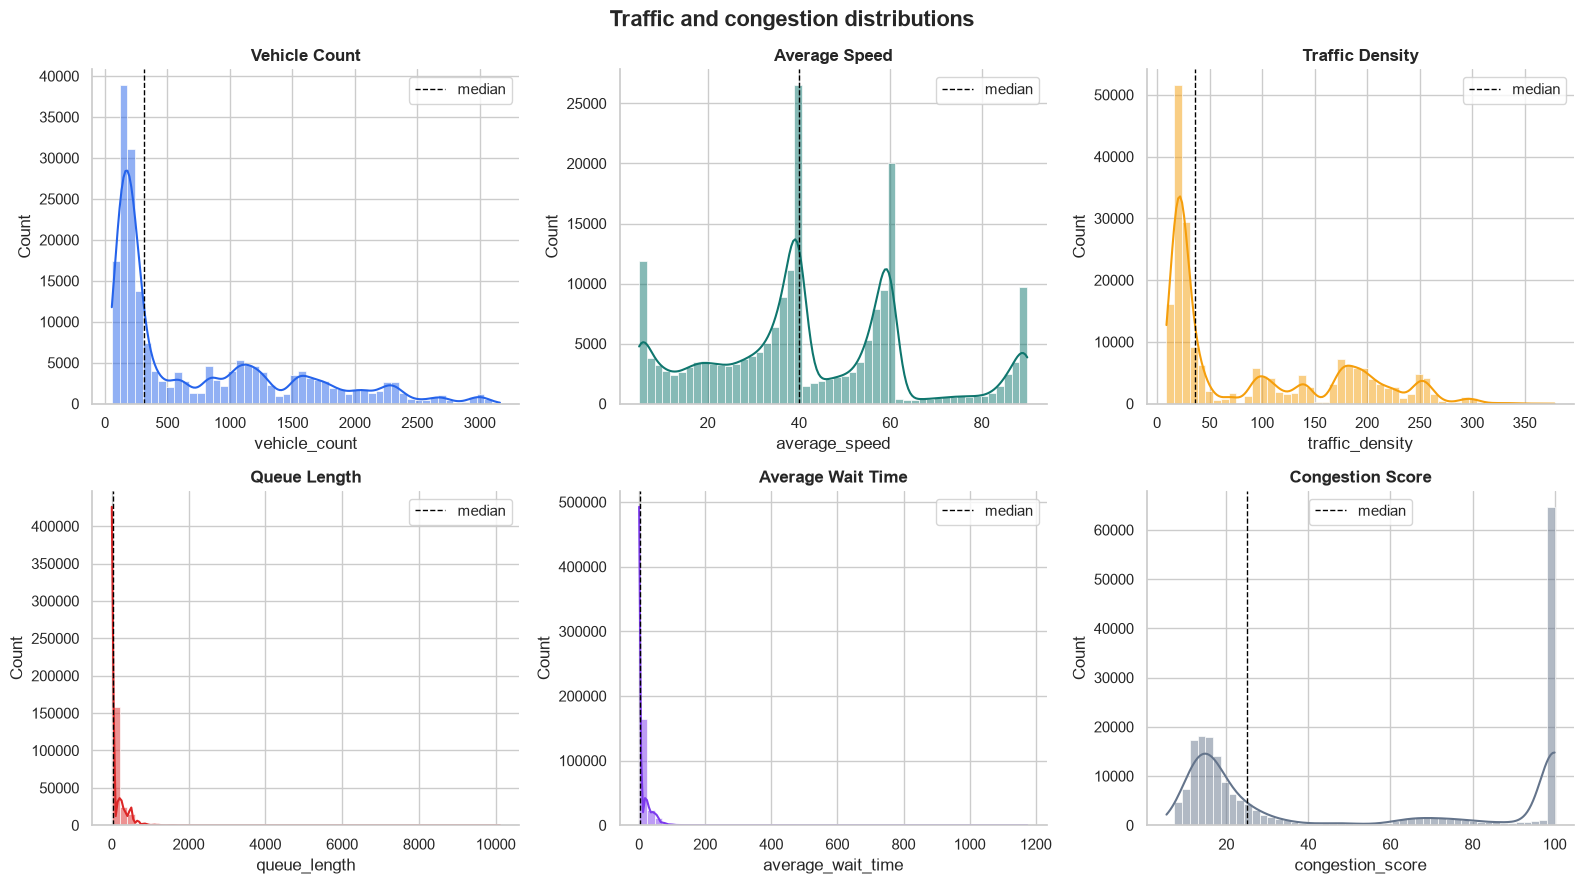

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_cols = ["vehicle_count", "average_speed", "traffic_density", "queue_length", "average_wait_time", "congestion_score"]
for ax, col, color in zip(axes.flat, plot_cols, COLORS):
    sea.histplot(df[col], bins=50, kde=True, ax=ax, color=color)
    ax.axvline(df[col].median(), color="black", linestyle="--", linewidth=1, label="median")
    ax.set_title(col.replace("_", " ").title())
    ax.legend()
fig.suptitle("Traffic and congestion distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

,records,congestion_score_mean,speed_mean,queue_p95,wait_mean,share_pct
congestion_level,,,,,,
Low,101679,15.48,54.83,44.60,1.48,49.84
Moderate,15976,32.63,50.40,48.70,1.64,7.83
High,14848,69.30,46.22,45.40,1.54,7.28
Severe,71497,98.99,21.67,719.00,31.87,35.05


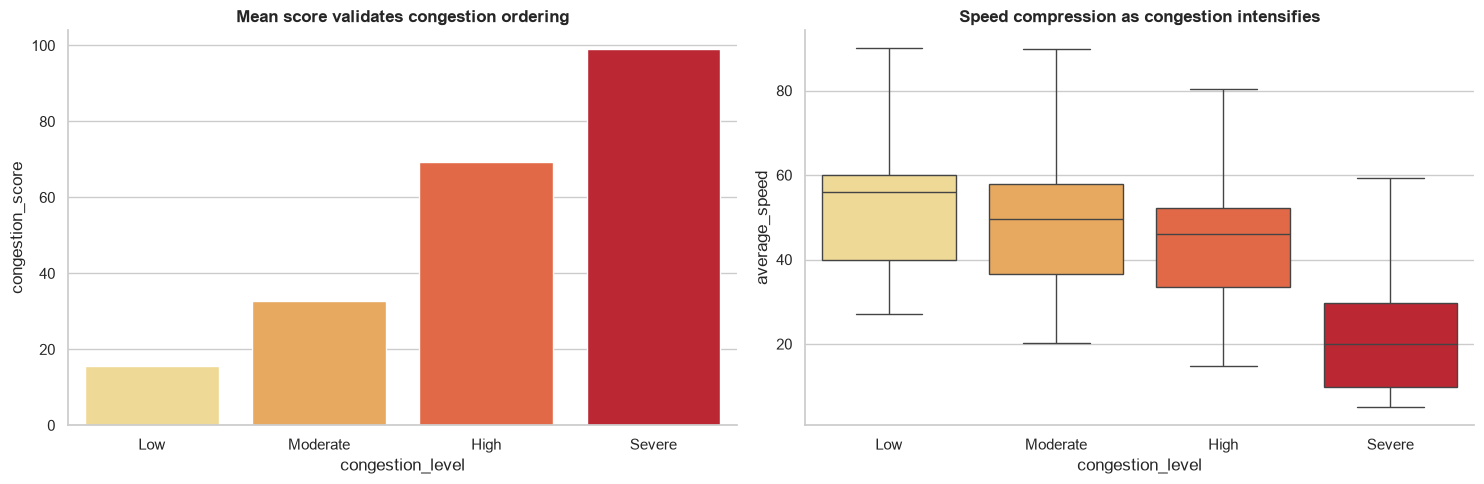

In [8]:
level_order = ["Low", "Moderate", "High", "Severe"]
level_summary = (df.groupby("congestion_level", observed=True)
                   .agg(records=("record_id", "size"),
                        congestion_score_mean=("congestion_score", "mean"),
                        speed_mean=("average_speed", "mean"),
                        queue_p95=("queue_length", lambda s: s.quantile(.95)),
                        wait_mean=("average_wait_time", "mean"))
                   .reindex(level_order))
level_summary["share_pct"] = 100 * level_summary["records"] / len(df)
display(level_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sea.barplot(data=df, x="congestion_level", y="congestion_score", order=level_order, estimator="mean", errorbar=None, ax=axes[0], palette="YlOrRd")
sea.boxplot(data=df.sample(min(40_000, len(df)), random_state=RANDOM_SEED), x="congestion_level", y="average_speed", order=level_order, showfliers=False, ax=axes[1], palette="YlOrRd")
axes[0].set_title("Mean score validates congestion ordering")
axes[1].set_title("Speed compression as congestion intensifies")
plt.tight_layout(); plt.show()

## 4. Temporal structure: trend, seasonality, and peak windows

Citywide totals answer system-capacity questions. Intersection-level means answer what a typical node experiences. Both are retained to avoid mixing scales.

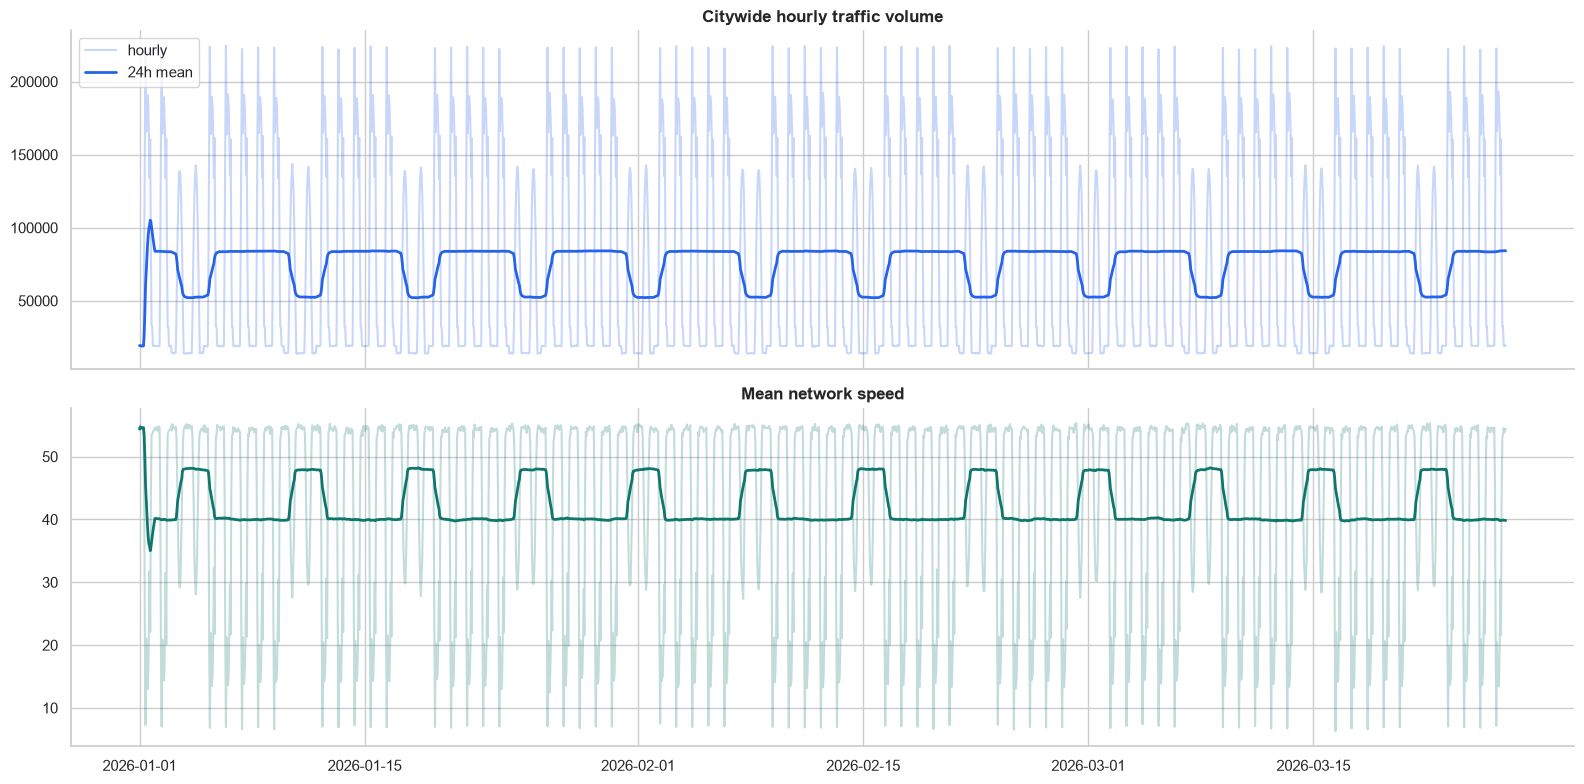

In [9]:
hourly_city = (df.groupby("timestamp", as_index=False)
                 .agg(vehicle_count_total=("vehicle_count", "sum"),
                      average_speed_mean=("average_speed", "mean"),
                      congestion_score_mean=("congestion_score", "mean"),
                      emission_total=("emission_estimate", "sum"),
                      incidents=("accident_reported", "sum")))
hourly_city["vehicle_24h_mean"] = hourly_city.vehicle_count_total.rolling(24, min_periods=1).mean()
hourly_city["speed_24h_mean"] = hourly_city.average_speed_mean.rolling(24, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(hourly_city.timestamp, hourly_city.vehicle_count_total, color=COLORS[0], alpha=.25, label="hourly")
axes[0].plot(hourly_city.timestamp, hourly_city.vehicle_24h_mean, color=COLORS[0], linewidth=2, label="24h mean")
axes[0].set_title("Citywide hourly traffic volume"); axes[0].legend()
axes[1].plot(hourly_city.timestamp, hourly_city.average_speed_mean, color=COLORS[1], alpha=.25)
axes[1].plot(hourly_city.timestamp, hourly_city.speed_24h_mean, color=COLORS[1], linewidth=2)
axes[1].set_title("Mean network speed")
plt.tight_layout(); plt.show()

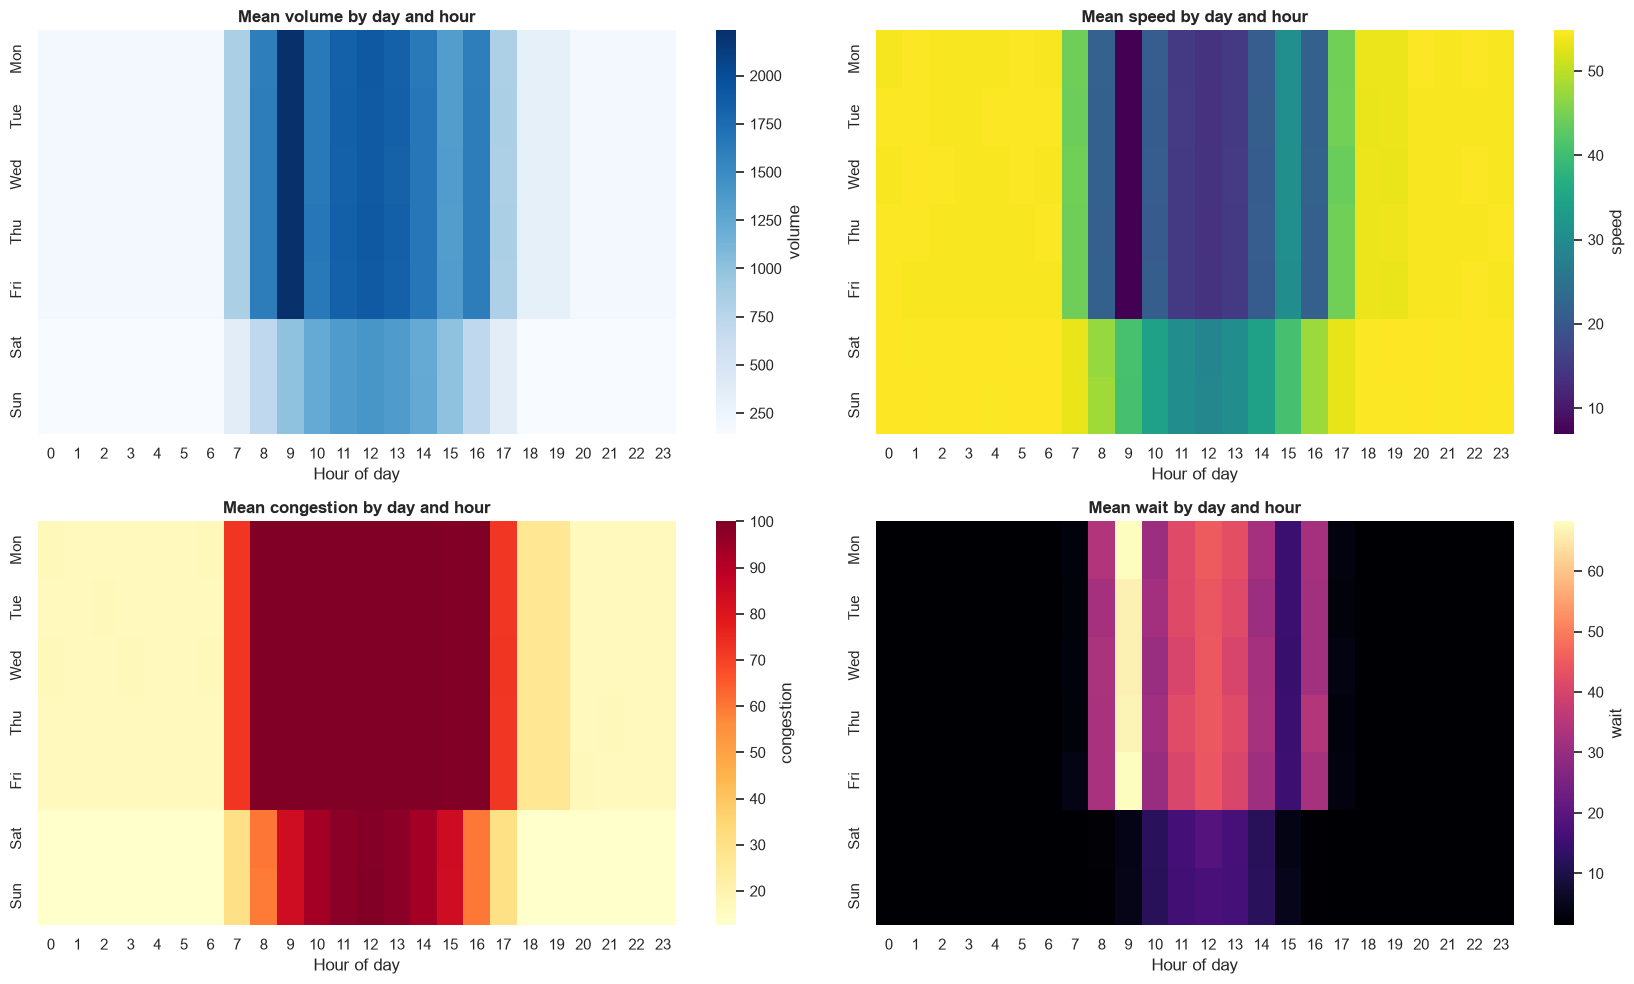

In [10]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
heat = (df.groupby(["day_of_week", "hour"], observed=True)
          .agg(volume=("vehicle_count", "mean"), speed=("average_speed", "mean"),
               congestion=("congestion_score", "mean"), wait=("average_wait_time", "mean"))
          .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
for ax, metric, cmap in zip(axes.flat, ["volume", "speed", "congestion", "wait"], ["Blues", "viridis", "YlOrRd", "magma"]):
    matrix = heat.pivot(index="day_of_week", columns="hour", values=metric).reindex(range(7))
    matrix.index = day_names
    sea.heatmap(matrix, cmap=cmap, ax=ax, cbar_kws={"label": metric})
    ax.set_title(f"Mean {metric} by day and hour")
    ax.set_xlabel("Hour of day"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

,peak_period,is_weekend,vehicle_count,average_speed,congestion_score,wait,queue_p95,day_type
2,Midday,0,"1,797.89",16.55,100.00,39.20,749.20,Weekday
4,Morning Peak,0,"1,561.74",24.19,90.81,34.41,884.63,Weekday
8,Off-Peak,0,902.55,38.26,58.21,15.25,505.80,Weekday
0,Evening Peak,0,774.19,43.14,56.58,9.69,352.40,Weekday
6,Night,0,190.93,54.42,16.53,1.51,45.10,Weekday
3,Midday,1,"1,334.48",31.08,96.95,15.57,447.58,Weekend
5,Morning Peak,1,690.80,47.17,58.03,2.60,69.31,Weekend
9,Off-Peak,1,669.10,44.84,52.31,6.15,254.80,Weekend
1,Evening Peak,1,339.58,52.44,28.97,1.58,45.80,Weekend
7,Night,1,141.48,54.66,12.74,1.51,46.00,Weekend


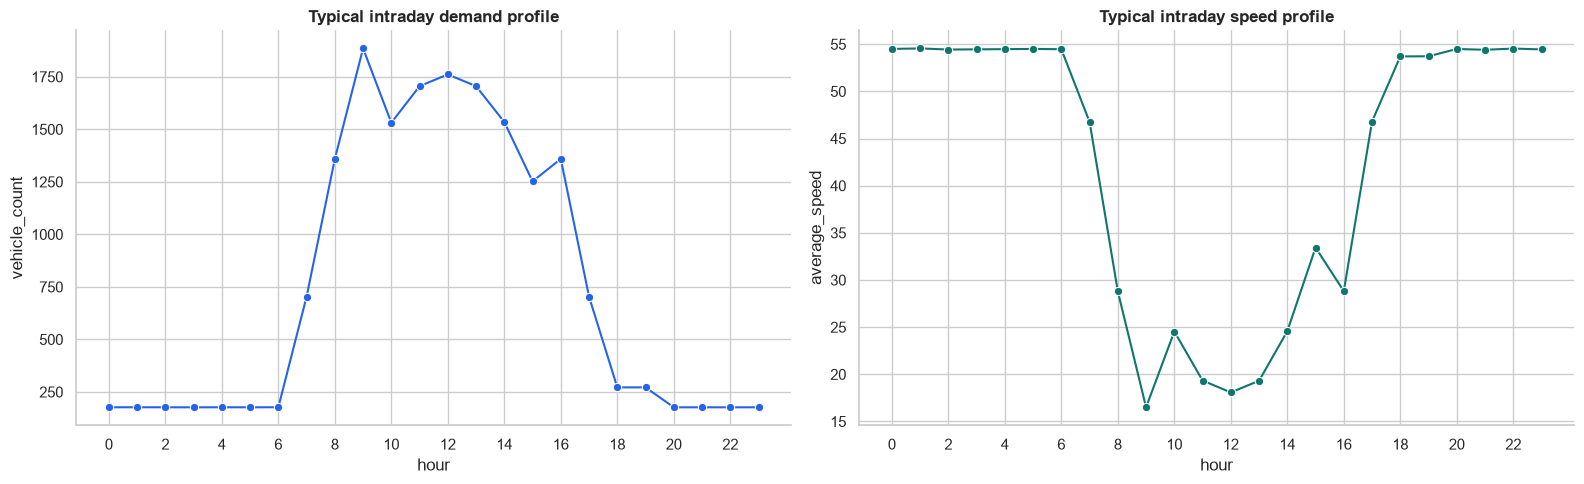

In [11]:
period_summary = (df.groupby(["peak_period", "is_weekend"], observed=True)
                    .agg(vehicle_count=("vehicle_count", "mean"), average_speed=("average_speed", "mean"),
                         congestion_score=("congestion_score", "mean"), wait=("average_wait_time", "mean"),
                         queue_p95=("queue_length", lambda s: s.quantile(.95)))
                    .reset_index())
period_summary["day_type"] = period_summary.is_weekend.map({0: "Weekday", 1: "Weekend"})
display(period_summary.sort_values(["day_type", "congestion_score"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sea.lineplot(data=df.groupby("hour", as_index=False).agg(vehicle_count=("vehicle_count", "mean"), average_speed=("average_speed", "mean")), x="hour", y="vehicle_count", marker="o", ax=axes[0], color=COLORS[0])
sea.lineplot(data=df.groupby("hour", as_index=False).agg(vehicle_count=("vehicle_count", "mean"), average_speed=("average_speed", "mean")), x="hour", y="average_speed", marker="o", ax=axes[1], color=COLORS[1])
axes[0].set_title("Typical intraday demand profile")
axes[1].set_title("Typical intraday speed profile")
for ax in axes: ax.set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

## 5. Spatial and roadway operating profiles

Zone and road-type comparisons help distinguish networkwide timing issues from localized design/capacity issues. Sample sizes are reported so small groups are not overinterpreted.

In [12]:
def grouped_profile(group_col):
    return (df.groupby(group_col, observed=True)
              .agg(records=("record_id", "size"), intersections=("intersection_id", "nunique"),
                   vehicle_count=("vehicle_count", "mean"), average_speed=("average_speed", "mean"),
                   congestion_score=("congestion_score", "mean"), queue_p95=("queue_length", lambda s: s.quantile(.95)),
                   wait=("average_wait_time", "mean"), emissions=("emission_estimate", "mean"))
              .sort_values("congestion_score", ascending=False))

zone_profile = grouped_profile("city_zone")
road_profile = grouped_profile("road_type")
display(zone_profile, road_profile)

,records,intersections,vehicle_count,average_speed,congestion_score,queue_p95,wait,emissions
city_zone,,,,,,,,
Downtown Core,44880,22,838.08,39.31,52.48,641.70,15.89,310.04
Financial District,48960,24,895.61,42.18,52.45,636.81,15.85,330.68
Suburban North,53040,26,622.63,41.48,47.94,442.30,8.98,195.40
Residential West,18360,9,644.05,42.59,47.93,436.10,8.76,200.86
Tech Park,22440,11,702.50,48.37,47.88,450.91,9.20,221.03
Industrial East,16320,8,664.24,44.05,47.87,442.41,8.91,208.12


,records,intersections,vehicle_count,average_speed,congestion_score,queue_p95,wait,emissions
road_type,,,,,,,,
Arterial,83640,41,842.82,44.16,50.51,540.90,13.08,296.22
Local Street,28560,14,540.68,29.84,50.02,527.30,12.14,185.86
Highway,34680,17,"1,063.98",67.72,49.56,484.30,11.25,354.32
Collector,57120,28,526.64,30.15,49.54,511.10,11.34,177.53


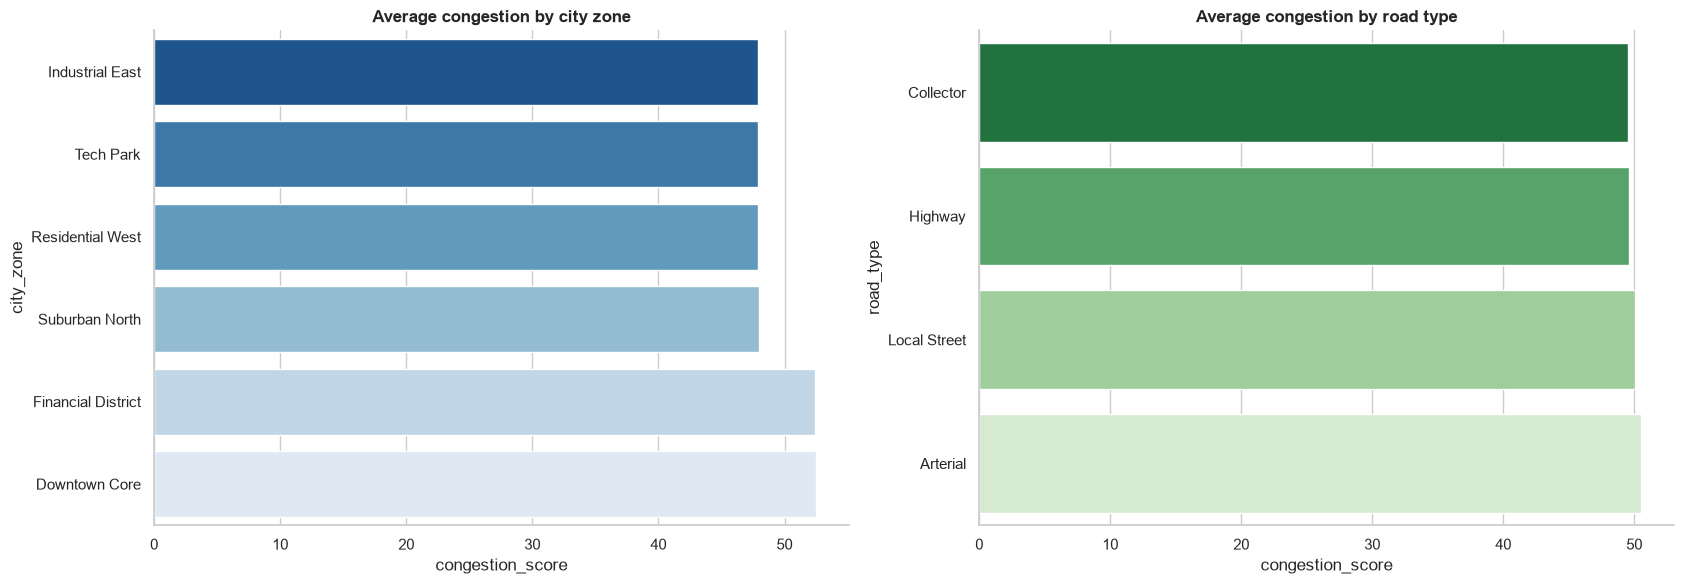

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
zone_plot = zone_profile.reset_index().sort_values("congestion_score")
road_plot = road_profile.reset_index().sort_values("congestion_score")
sea.barplot(data=zone_plot, y="city_zone", x="congestion_score", ax=axes[0], palette="Blues_r")
sea.barplot(data=road_plot, y="road_type", x="congestion_score", ax=axes[1], palette="Greens_r")
axes[0].set_title("Average congestion by city zone")
axes[1].set_title("Average congestion by road type")
plt.tight_layout(); plt.show()

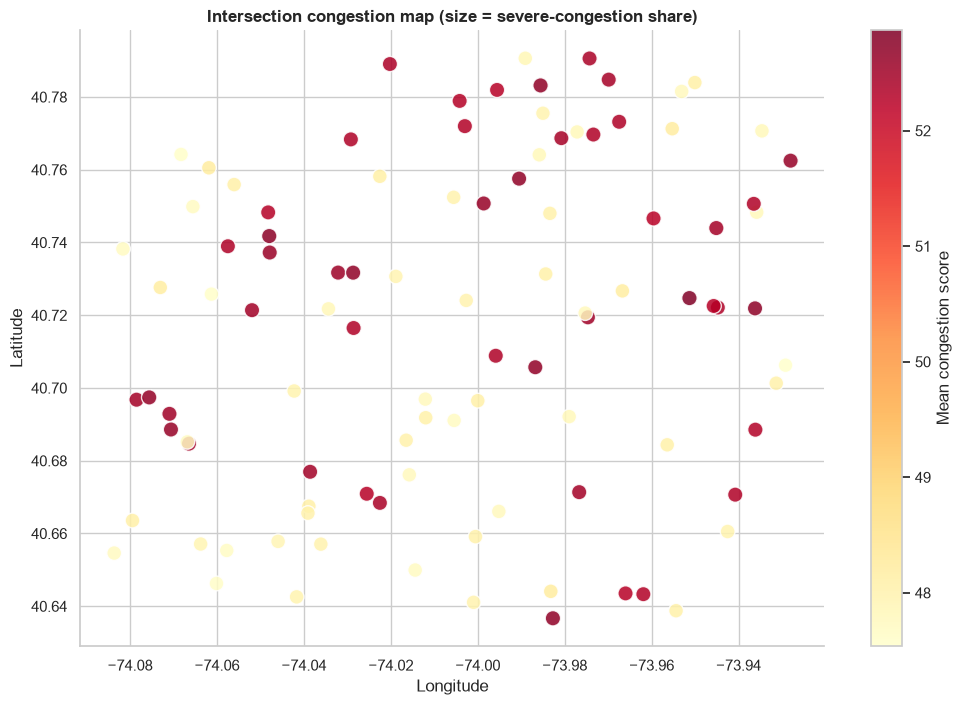

In [14]:
intersection_geo = (df.groupby("intersection_id", as_index=False)
                      .agg(latitude=("latitude", "first"), longitude=("longitude", "first"),
                           city_zone=("city_zone", "first"), road_type=("road_type", "first"),
                           congestion_score=("congestion_score", "mean"),
                           vehicle_count=("vehicle_count", "mean"), average_speed=("average_speed", "mean"),
                           severe_share=("congestion_level", lambda s: (s == "Severe").mean())))

plt.figure(figsize=(12, 8))
points = plt.scatter(intersection_geo.longitude, intersection_geo.latitude,
                     c=intersection_geo.congestion_score, s=40 + 220 * intersection_geo.severe_share,
                     cmap="YlOrRd", alpha=.85, edgecolor="white")
plt.colorbar(points, label="Mean congestion score")
plt.title("Intersection congestion map (size = severe-congestion share)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()

## 6. Weather, incidents, events, and infrastructure context

To keep comparisons readable, the next tables report group means and **relative deltas** against a sensible reference. They are descriptive; weather and incidents co-occur with time and location patterns.

vehicle_count                average_speed                 \
                           mean median   count          mean median   count   
weather_condition                                                             
Clear                    750.65 308.00  183664         42.80  40.00  183664   
Fog                      718.64 250.50     222         33.70  32.50     222   
Heavy Rain               749.08 321.50    5542         32.26  31.20    5542   
Rain                     736.86 301.00   14572         39.10  36.80   14572   

                  congestion_score                queue_length                 \
                              mean median   count         mean median   count   
weather_condition                                                               
Clear                        49.63  24.00  183664       119.32  19.00  183664   
Fog                          54.08  30.80     222       191.21  19.40     222   
Heavy Rain                   56.88  35.60    5542       195.16  22.30    5542   
Rain                         52.08  28.30   14572       119.46  18.50   14572   

                  average_wait_time                emission_estimate         \
                               mean median   count              mean median   
weather_condition                                                             
Clear                         11.93   1.90  183664            256.36  74.07   
Fog                           19.15   1.90     222            291.59  60.54   
Heavy Rain                    19.61   2.20    5542            304.78  78.22   
Rain                          11.95   1.80   14572            252.16  72.40   

                           
                    count  
weather_condition          
Clear              183664  
Fog                   222  
Heavy Rain           5542  
Rain                14572

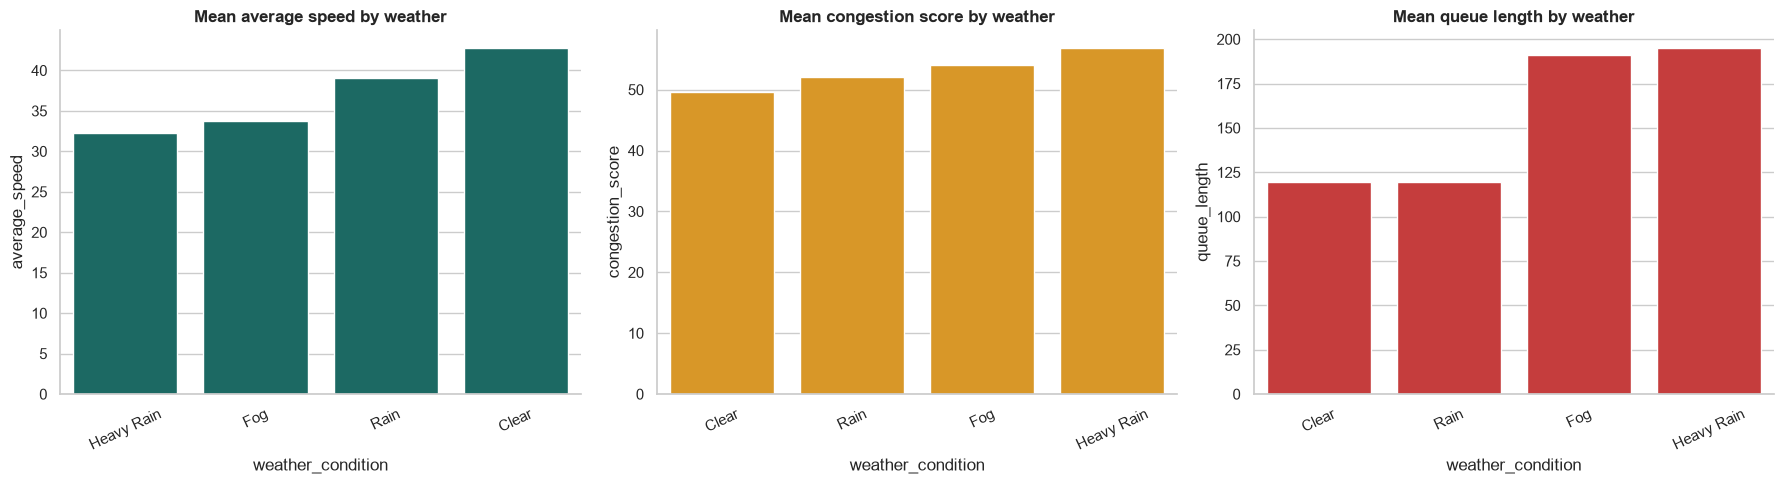

In [15]:
outcomes = ["vehicle_count", "average_speed", "congestion_score", "queue_length", "average_wait_time", "emission_estimate"]

weather_summary = (df.groupby("weather_condition", observed=True)[outcomes]
                     .agg(["mean", "median", "count"]))
display(weather_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ["average_speed", "congestion_score", "queue_length"], COLORS[1:4]):
    order = df.groupby("weather_condition")[metric].mean().sort_values().index
    sea.barplot(data=df, x="weather_condition", y=metric, order=order, estimator="mean", errorbar=None, ax=ax, color=color)
    ax.set_title(f"Mean {metric.replace('_', ' ')} by weather")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

In [16]:
def binary_effect(col, label=None):
    summary = df.groupby(col)[outcomes].mean().T
    summary.columns = [f"{col}=0", f"{col}=1"]
    summary["absolute_delta"] = summary.iloc[:, 1] - summary.iloc[:, 0]
    summary["relative_delta_pct"] = 100 * summary["absolute_delta"] / summary.iloc[:, 0].replace(0, np.nan)
    summary.insert(0, "context", label or col)
    return summary.reset_index(names="metric")

context_effects = pd.concat([
    binary_effect("accident_reported", "Accident"),
    binary_effect("construction_activity", "Construction"),
    binary_effect("public_event", "Public event"),
    binary_effect("emergency_vehicle_detected", "Emergency vehicle"),
    binary_effect("rush_hour", "Rush hour"),
], ignore_index=True)
display(context_effects.pivot(index="context", columns="metric", values="relative_delta_pct").round(1))

metric,average_speed,average_wait_time,congestion_score,emission_estimate,queue_length,vehicle_count
context,,,,,,
Accident,-31.30,466.90,25.50,141.00,468.50,13.70
Construction,-11.10,118.20,1.70,32.40,118.10,-1.60
Emergency vehicle,0.10,3.90,1.80,2.30,3.60,1.90
Public event,-12.20,80.40,11.60,61.00,81.40,32.40
Rush hour,-20.70,102.90,60.50,87.20,103.10,70.10


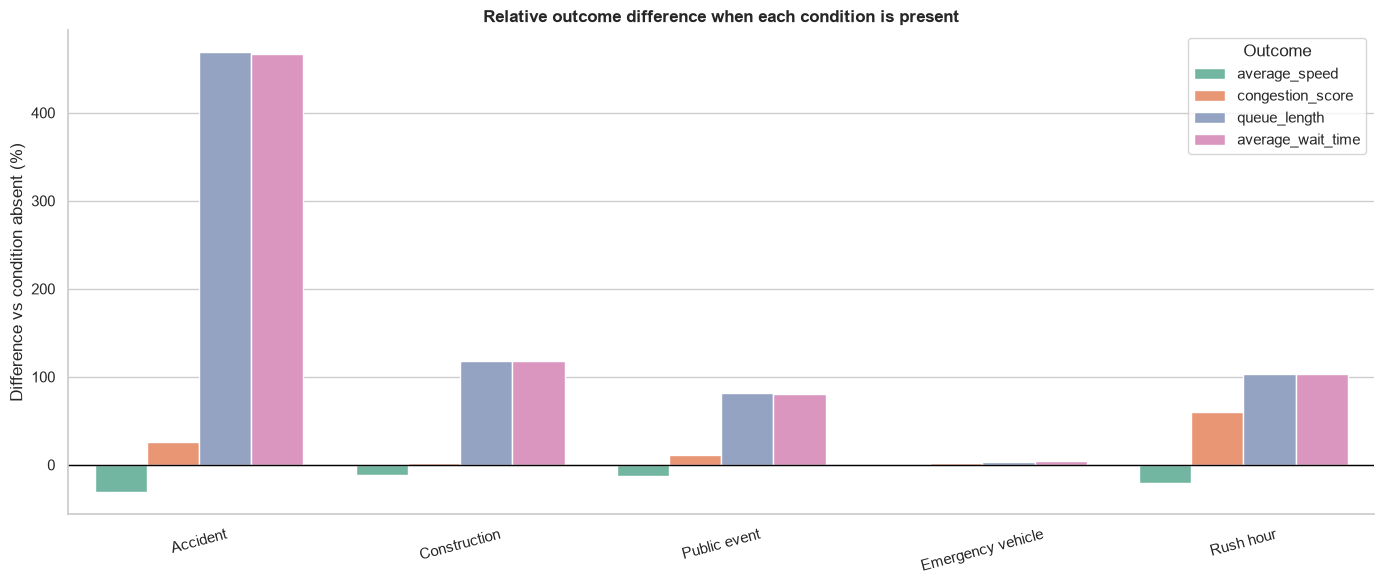

In [17]:
event_metrics = context_effects[context_effects.metric.isin(["average_speed", "congestion_score", "queue_length", "average_wait_time"])]
plt.figure(figsize=(14, 6))
sea.barplot(data=event_metrics, x="context", y="relative_delta_pct", hue="metric", palette="Set2")
plt.axhline(0, color="black", linewidth=1)
plt.title("Relative outcome difference when each condition is present")
plt.ylabel("Difference vs condition absent (%)"); plt.xlabel("")
plt.xticks(rotation=15); plt.legend(title="Outcome")
plt.tight_layout(); plt.show()

## 7. Traffic-flow mechanics: volume, speed, density, queues, and delay

Traffic variables are mechanically related in the simulation, so correlation is expected. Hexbin plots reveal the dense operating region without overplotting 204,000 points.

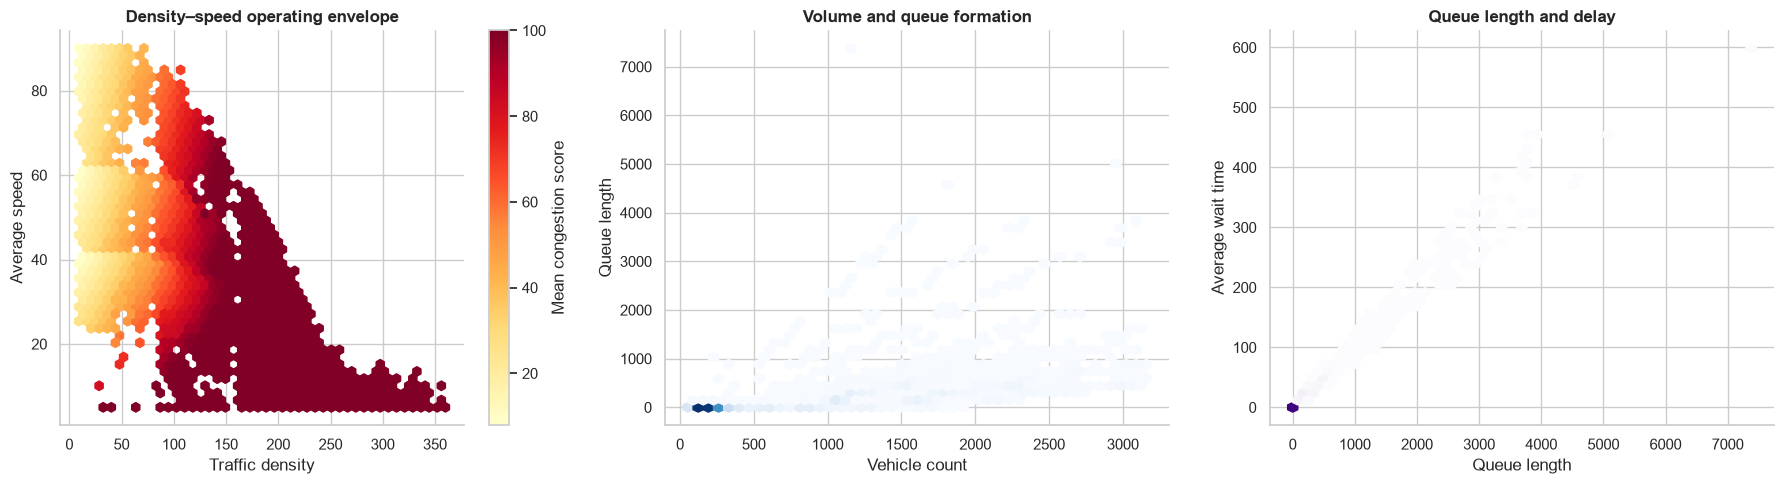

In [18]:
sample = df.sample(min(60_000, len(df)), random_state=RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hb = axes[0].hexbin(sample.traffic_density, sample.average_speed, C=sample.congestion_score, reduce_C_function=np.mean, gridsize=45, cmap="YlOrRd", mincnt=1)
fig.colorbar(hb, ax=axes[0], label="Mean congestion score")
axes[0].set_title("Density–speed operating envelope"); axes[0].set_xlabel("Traffic density"); axes[0].set_ylabel("Average speed")
axes[1].hexbin(sample.vehicle_count, sample.queue_length, gridsize=45, cmap="Blues", mincnt=1)
axes[1].set_title("Volume and queue formation"); axes[1].set_xlabel("Vehicle count"); axes[1].set_ylabel("Queue length")
axes[2].hexbin(sample.queue_length, sample.average_wait_time, gridsize=45, cmap="Purples", mincnt=1)
axes[2].set_title("Queue length and delay"); axes[2].set_xlabel("Queue length"); axes[2].set_ylabel("Average wait time")
plt.tight_layout(); plt.show()

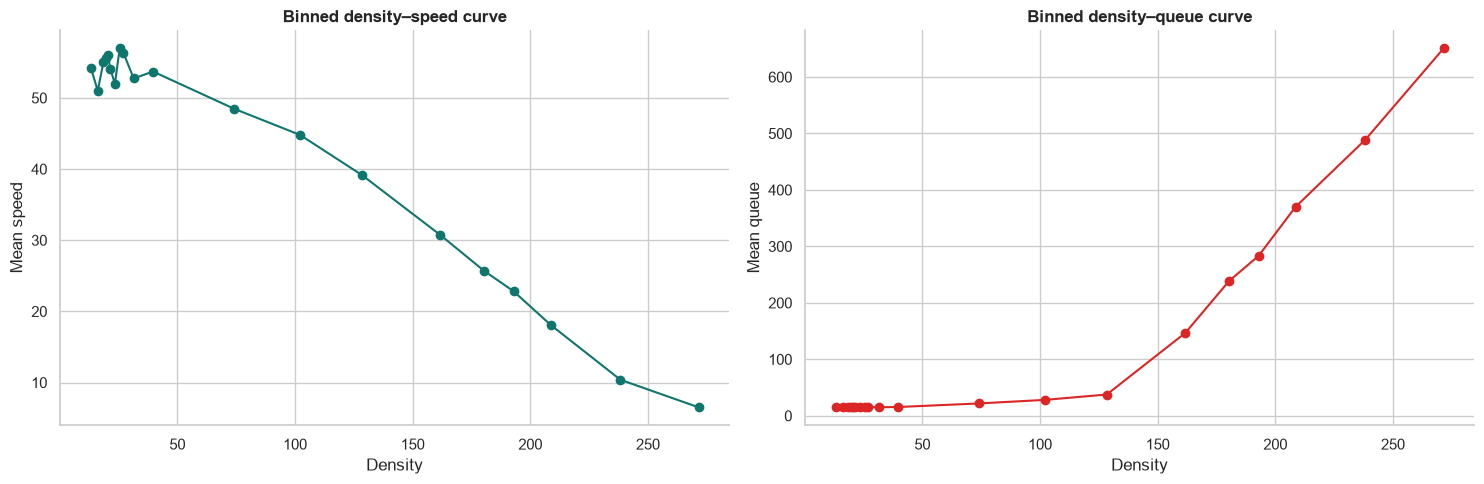

,density,speed,flow,congestion,queue
density_band,,,,,
"(8.999, 14.4]",13.19,54.26,107.68,10.33,15.01
"(14.4, 17.8]",16.14,51.02,124.62,12.23,14.98
"(17.8, 19.1]",18.58,55.04,154.27,13.68,14.92
"(19.1, 20.0]",19.61,55.57,163.67,14.32,15.14
"(20.0, 20.8]",20.46,56.02,172.12,14.88,15.12
"(20.8, 22.2]",21.49,54.08,176.06,15.53,14.99
"(22.2, 24.6]",23.45,51.97,187.03,16.83,15.01
"(24.6, 26.2]",25.48,56.95,220.13,17.97,15.34
"(26.2, 27.9]",27.03,56.36,231.91,18.99,15.22


In [19]:
density_bins = pd.qcut(df.traffic_density, q=20, duplicates="drop")
fundamental = (df.assign(density_band=density_bins)
                 .groupby("density_band", observed=True)
                 .agg(density=("traffic_density", "mean"), speed=("average_speed", "mean"),
                      flow=("traffic_flow_rate", "mean"), congestion=("congestion_score", "mean"),
                      queue=("queue_length", "mean")))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(fundamental.density, fundamental.speed, marker="o", color=COLORS[1])
axes[0].set_title("Binned density–speed curve"); axes[0].set_xlabel("Density"); axes[0].set_ylabel("Mean speed")
axes[1].plot(fundamental.density, fundamental.queue, marker="o", color=COLORS[3])
axes[1].set_title("Binned density–queue curve"); axes[1].set_xlabel("Density"); axes[1].set_ylabel("Mean queue")
plt.tight_layout(); plt.show()
display(fundamental)

## 8. Association analysis: Pearson and Phi-K

- **Pearson** summarizes linear association among numeric measures.
- **Phi-K** handles numeric, ordinal, binary, and categorical variables in one matrix and can detect non-linear associations.

IDs, coordinates, and direct category labels derived from congestion score are excluded from the mixed-type matrix to reduce leakage-like redundancy and visual clutter.

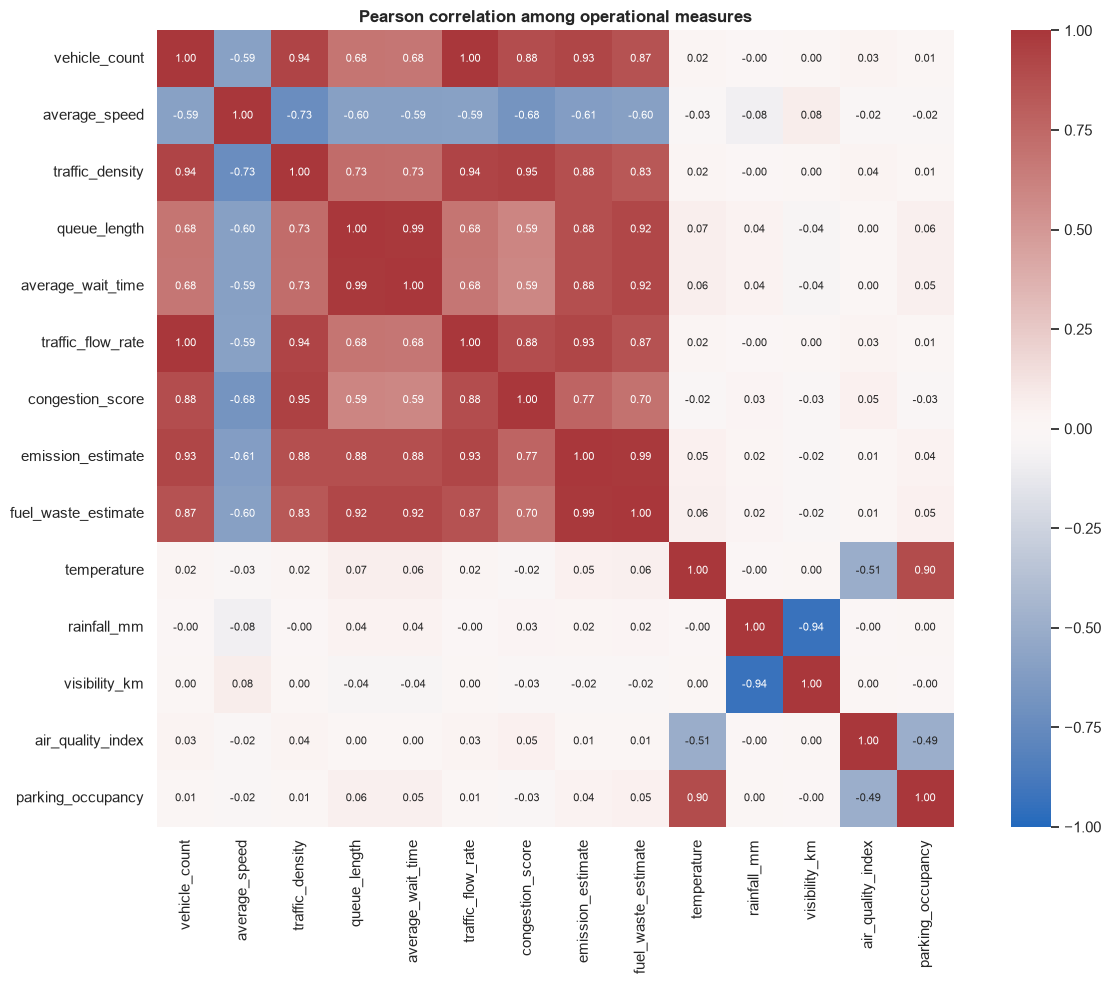

In [20]:
corr_cols = ["vehicle_count", "average_speed", "traffic_density", "queue_length", "average_wait_time",
             "traffic_flow_rate", "congestion_score", "emission_estimate", "fuel_waste_estimate",
             "temperature", "rainfall_mm", "visibility_km", "air_quality_index", "parking_occupancy"]
pearson = df[corr_cols].corr()
plt.figure(figsize=(13, 10))
sea.heatmap(pearson, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, annot_kws={"size": 8})
plt.title("Pearson correlation among operational measures")
plt.tight_layout(); plt.show()

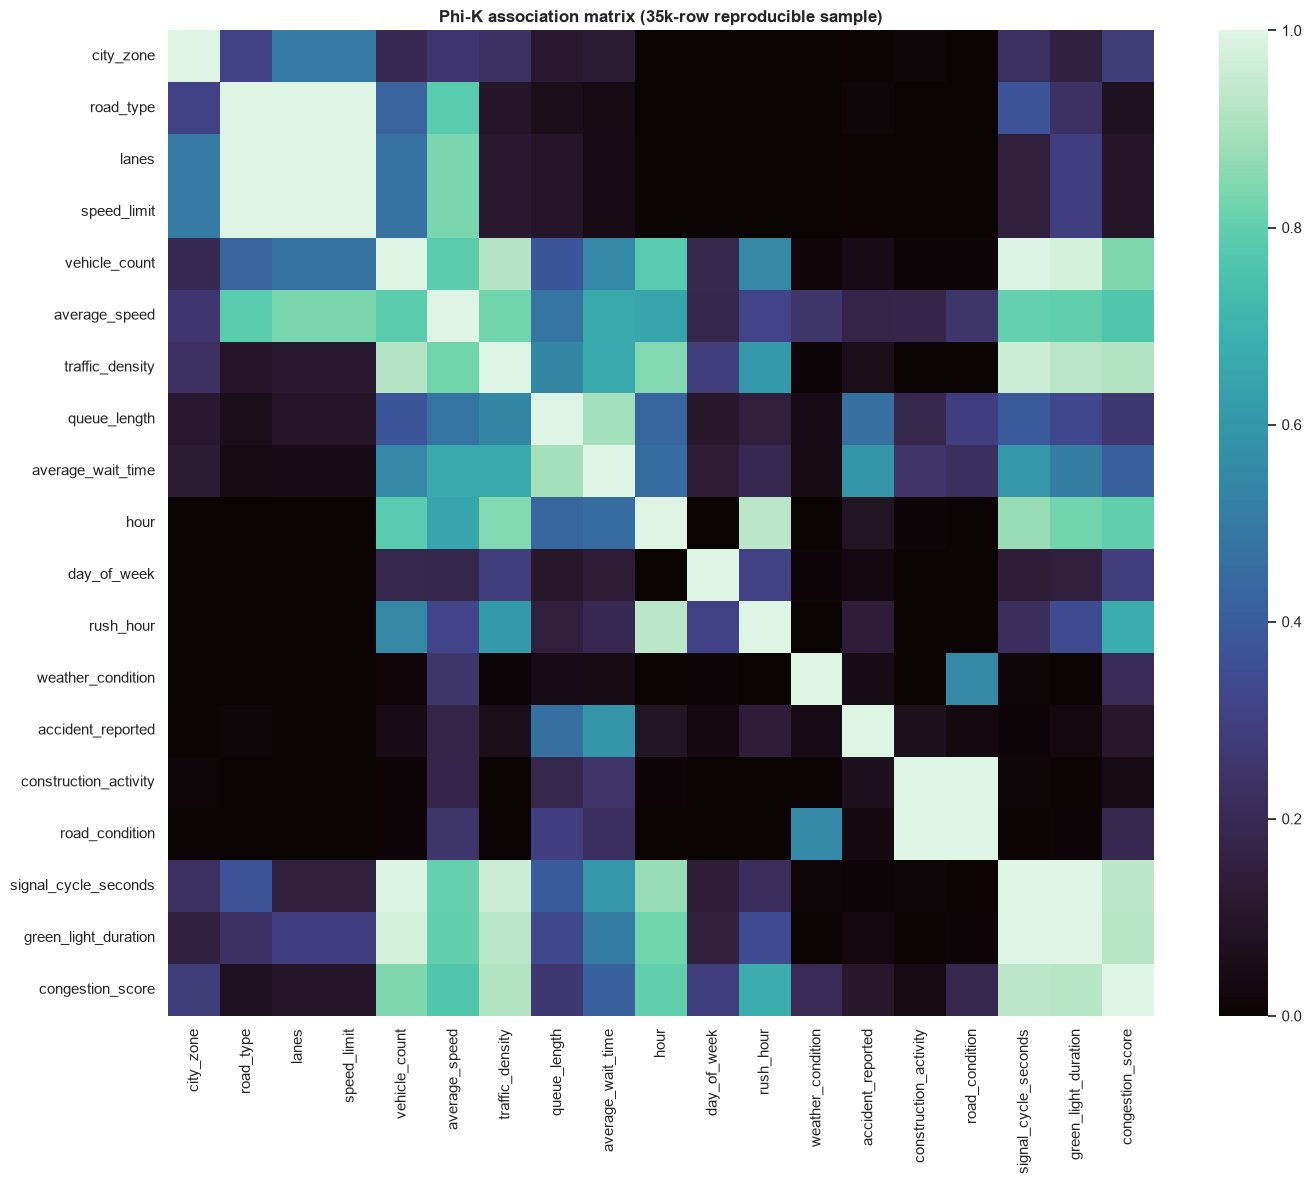

,Phi-K with congestion_score
signal_cycle_seconds,0.93
green_light_duration,0.93
traffic_density,0.92
vehicle_count,0.84
hour,0.80
average_speed,0.77
rush_hour,0.68
average_wait_time,0.41
day_of_week,0.29
city_zone,0.28


In [21]:
phik_cols = ["city_zone", "road_type", "lanes", "speed_limit", "vehicle_count", "average_speed",
             "traffic_density", "queue_length", "average_wait_time", "hour", "day_of_week", "rush_hour",
             "weather_condition", "accident_reported", "construction_activity", "road_condition",
             "signal_cycle_seconds", "green_light_duration", "congestion_score"]
phik_sample = df[phik_cols].sample(min(35_000, len(df)), random_state=RANDOM_SEED)
interval_cols = [c for c in phik_cols if pd.api.types.is_numeric_dtype(phik_sample[c]) and c not in ["lanes", "speed_limit", "hour", "day_of_week", "rush_hour", "accident_reported", "construction_activity", "signal_cycle_seconds"]]
phik_matrix = phik_sample.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(15, 12))
sea.heatmap(phik_matrix, cmap="mako", vmin=0, vmax=1, square=True)
plt.title("Phi-K association matrix (35k-row reproducible sample)")
plt.tight_layout(); plt.show()

display(phik_matrix["congestion_score"].drop("congestion_score").sort_values(ascending=False).to_frame("Phi-K with congestion_score"))

## 9. Signal timing and operational efficiency

Signal-cycle comparisons are stratified by rush hour to reduce a common confound: longer cycles may be deployed precisely where demand is highest.

,signal_cycle_seconds,rush_hour,records,vehicle_count,wait,queue,congestion,speed,period
0,60,0,125717,315.24,3.35,33.52,28.81,49.94,Non-rush
1,60,1,26691,614.64,5.28,52.88,54.74,44.47,Rush hour
2,120,0,35583,"1,849.59",33.47,334.42,99.42,23.66,Non-rush
3,120,1,16009,"1,940.47",45.29,453.13,98.78,19.26,Rush hour


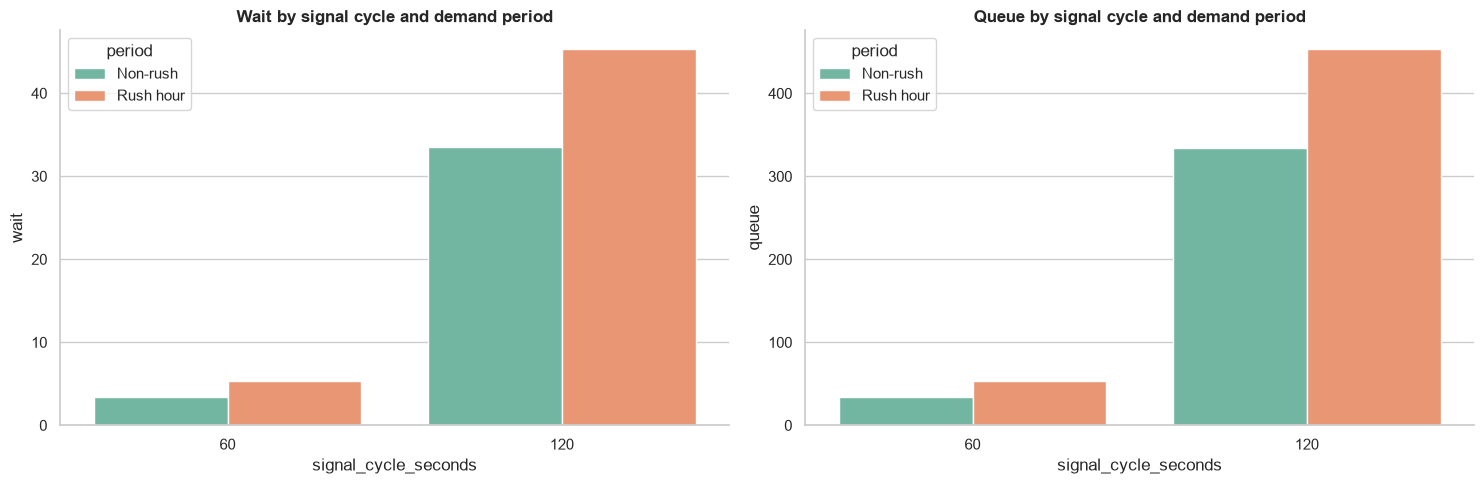

In [22]:
signal = (df.groupby(["signal_cycle_seconds", "rush_hour"], observed=True)
            .agg(records=("record_id", "size"), vehicle_count=("vehicle_count", "mean"),
                 wait=("average_wait_time", "mean"), queue=("queue_length", "mean"),
                 congestion=("congestion_score", "mean"), speed=("average_speed", "mean"))
            .reset_index())
signal["period"] = signal.rush_hour.map({0: "Non-rush", 1: "Rush hour"})
display(signal)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sea.barplot(data=signal, x="signal_cycle_seconds", y="wait", hue="period", ax=axes[0], palette="Set2")
sea.barplot(data=signal, x="signal_cycle_seconds", y="queue", hue="period", ax=axes[1], palette="Set2")
axes[0].set_title("Wait by signal cycle and demand period")
axes[1].set_title("Queue by signal cycle and demand period")
plt.tight_layout(); plt.show()

,city_zone,road_type,vehicle_count,emissions,fuel_waste,wait,congestion,kg_co2_per_1000_vehicles,fuel_waste_per_1000_vehicles
7,Financial District,Local Street,3780324,"1,417,730.39","417,355.75",16.34,52.74,375.03,110.40
5,Financial District,Collector,3775460,"1,412,398.10","415,300.00",16.16,52.66,374.10,110.00
0,Downtown Core,Arterial,18893166,"7,046,920.18","2,069,151.72",16.09,52.40,372.99,109.52
1,Downtown Core,Collector,7554080,"2,815,235.69","826,297.59",16.05,52.66,372.68,109.38
4,Financial District,Arterial,26432374,"9,828,262.75","2,881,549.09",15.95,52.40,371.83,109.02
3,Downtown Core,Local Street,3768548,"1,391,838.40","406,758.76",15.74,52.56,369.33,107.94
2,Downtown Core,Highway,7397068,"2,660,622.22","767,521.32",15.09,52.29,359.69,103.76
6,Financial District,Highway,9860696,"3,531,721.48","1,016,639.81",14.91,52.28,358.16,103.10
23,Tech Park,Local Street,1975005,"636,305.40","172,859.20",9.83,48.06,322.18,87.52
21,Tech Park,Collector,2961162,"942,830.34","254,324.83",9.50,48.09,318.40,85.89


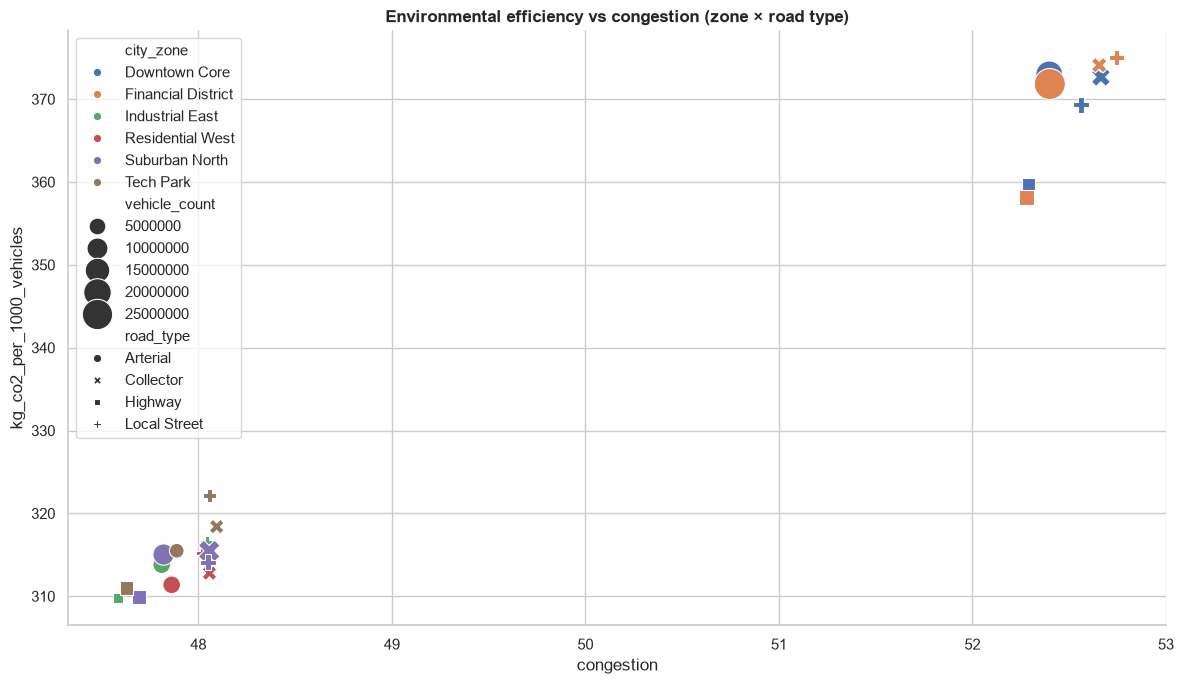

In [23]:
efficiency = (df.groupby(["city_zone", "road_type"], observed=True)
                .agg(vehicle_count=("vehicle_count", "sum"), emissions=("emission_estimate", "sum"),
                     fuel_waste=("fuel_waste_estimate", "sum"), wait=("average_wait_time", "mean"),
                     congestion=("congestion_score", "mean"))
                .reset_index())
efficiency["kg_co2_per_1000_vehicles"] = 1000 * efficiency.emissions / efficiency.vehicle_count
efficiency["fuel_waste_per_1000_vehicles"] = 1000 * efficiency.fuel_waste / efficiency.vehicle_count
display(efficiency.sort_values("kg_co2_per_1000_vehicles", ascending=False))

plt.figure(figsize=(12, 7))
sea.scatterplot(data=efficiency, x="congestion", y="kg_co2_per_1000_vehicles", size="vehicle_count", hue="city_zone", style="road_type", sizes=(80, 500))
plt.title("Environmental efficiency vs congestion (zone × road type)")
plt.tight_layout(); plt.show()

## 10. Intersection segmentation with K-means clustering

Each intersection is summarized by long-run operating features. Features are standardized before clustering so large-unit variables do not dominate. The cluster count is selected from 2–6 using silhouette score, then interpreted through original-scale profiles.

This is **descriptive segmentation**, not prediction. Cluster labels are arbitrary and should be renamed by their operational profile.

,k,silhouette_score,inertia
0,2,0.39,745.81
1,3,0.46,471.05
2,4,0.47,335.35
3,5,0.50,256.85
4,6,0.52,184.33


Selected k=6 using the highest silhouette score.


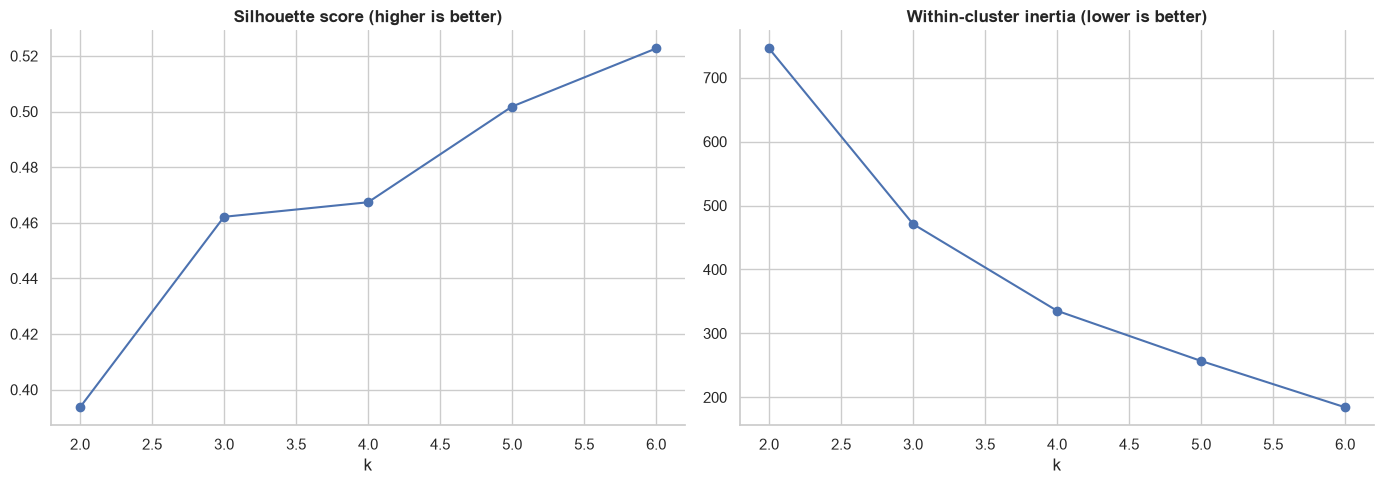

In [24]:
intersection_features = (df.groupby("intersection_id")
    .agg(city_zone=("city_zone", "first"), road_type=("road_type", "first"), latitude=("latitude", "first"), longitude=("longitude", "first"),
         lanes=("lanes", "first"), speed_limit=("speed_limit", "first"), vehicle_count_mean=("vehicle_count", "mean"),
         vehicle_count_p95=("vehicle_count", lambda s: s.quantile(.95)), average_speed_mean=("average_speed", "mean"),
         congestion_mean=("congestion_score", "mean"), severe_share=("congestion_level", lambda s: (s == "Severe").mean()),
         queue_p95=("queue_length", lambda s: s.quantile(.95)), wait_mean=("average_wait_time", "mean"),
         accident_rate=("accident_reported", "mean"), emission_per_record=("emission_estimate", "mean"),
         fuel_waste_per_record=("fuel_waste_estimate", "mean"), parking_occupancy=("parking_occupancy", "mean"))
    .reset_index())

cluster_features = ["lanes", "speed_limit", "vehicle_count_mean", "vehicle_count_p95", "average_speed_mean",
                    "congestion_mean", "severe_share", "queue_p95", "wait_mean", "accident_rate",
                    "emission_per_record", "fuel_waste_per_record", "parking_occupancy"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(intersection_features[cluster_features])

scores = []
models = {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_SEED)
    labels = model.fit_predict(X_scaled)
    scores.append({"k": k, "silhouette_score": silhouette_score(X_scaled, labels), "inertia": model.inertia_})
    models[k] = model
cluster_selection = pd.DataFrame(scores)
best_k = int(cluster_selection.loc[cluster_selection.silhouette_score.idxmax(), "k"])
intersection_features["cluster"] = models[best_k].labels_.astype(int)

display(cluster_selection)
print(f"Selected k={best_k} using the highest silhouette score.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cluster_selection.k, cluster_selection.silhouette_score, marker="o")
axes[0].set_title("Silhouette score (higher is better)"); axes[0].set_xlabel("k")
axes[1].plot(cluster_selection.k, cluster_selection.inertia, marker="o")
axes[1].set_title("Within-cluster inertia (lower is better)"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

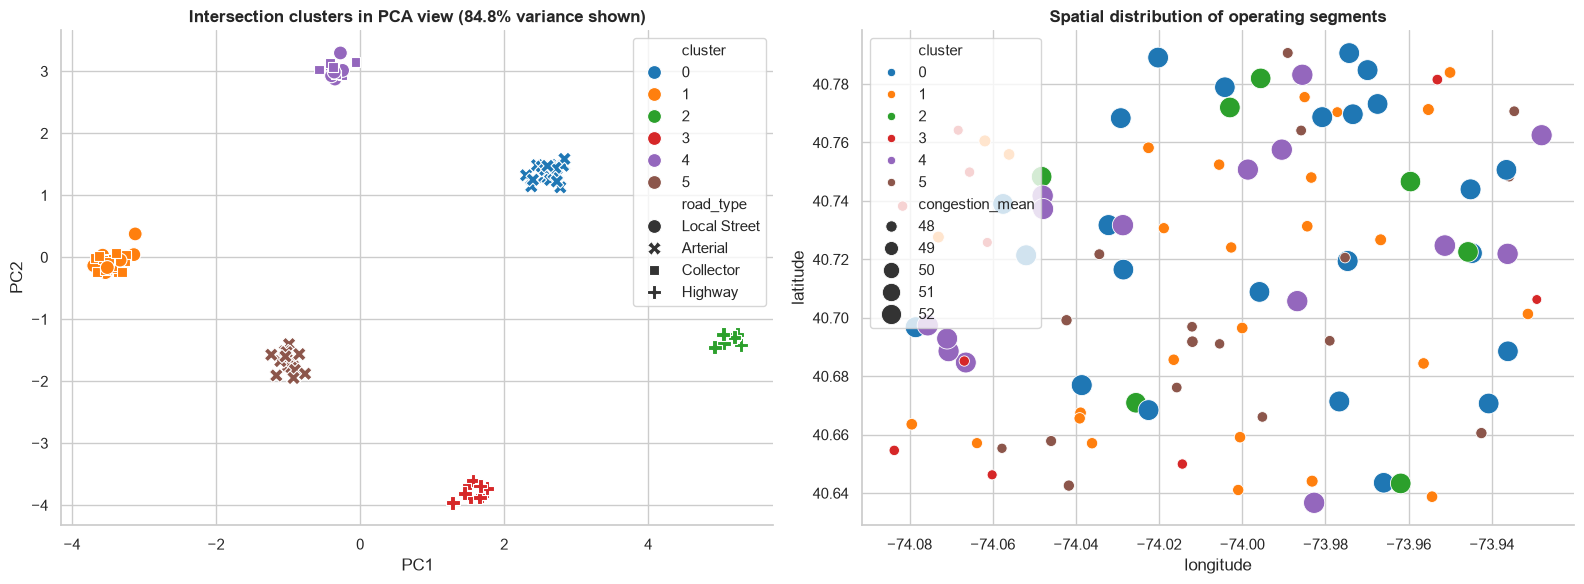

In [25]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)
intersection_features["PC1"] = coords[:, 0]
intersection_features["PC2"] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sea.scatterplot(data=intersection_features, x="PC1", y="PC2", hue="cluster", style="road_type", s=100, palette="tab10", ax=axes[0])
axes[0].set_title(f"Intersection clusters in PCA view ({pca.explained_variance_ratio_.sum():.1%} variance shown)")
sea.scatterplot(data=intersection_features, x="longitude", y="latitude", hue="cluster", size="congestion_mean", sizes=(50, 240), palette="tab10", ax=axes[1])
axes[1].set_title("Spatial distribution of operating segments")
plt.tight_layout(); plt.show()

,intersections
cluster,
0,24
1,27
2,7
3,10
4,15
5,17


,lanes,speed_limit,vehicle_count_mean,vehicle_count_p95,average_speed_mean,congestion_mean,severe_share,queue_p95,wait_mean,accident_rate,emission_per_record,fuel_waste_per_record,parking_occupancy
cluster,,,,,,,,,,,,,
0,3.00,60.00,925.77,"2,353.44",42.16,52.40,0.37,655.96,16.01,0.02,344.67,101.12,40.69
1,2.00,40.00,483.75,"1,221.39",31.12,48.06,0.33,446.33,9.13,0.02,152.72,40.98,40.72
2,4.00,90.00,"1,208.53","3,012.44",63.36,52.28,0.37,503.34,14.98,0.02,433.64,124.94,40.66
3,4.00,90.00,962.80,"2,420.96",70.76,47.66,0.33,421.49,8.64,0.02,298.80,79.34,40.76
4,2.00,40.00,616.94,"1,572.92",28.12,52.66,0.37,654.37,16.06,0.02,229.97,67.51,40.69
5,3.00,60.00,725.71,"1,819.05",46.97,47.84,0.33,435.25,8.94,0.02,227.83,60.93,40.73


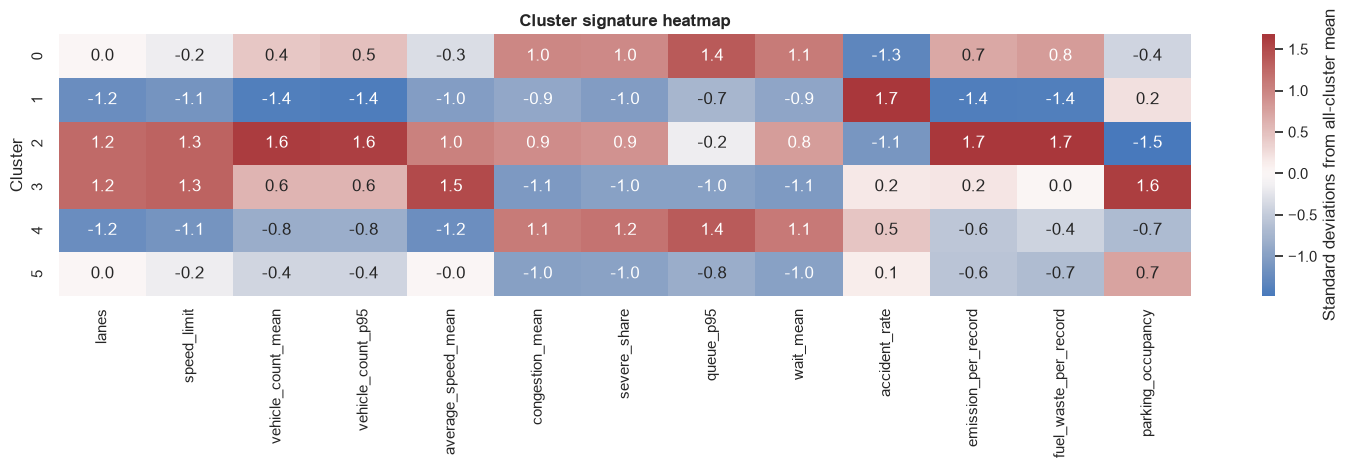

In [26]:
cluster_profile = intersection_features.groupby("cluster")[cluster_features].mean()
cluster_z = pd.DataFrame(StandardScaler().fit_transform(cluster_profile), index=cluster_profile.index, columns=cluster_profile.columns)
cluster_sizes = intersection_features.cluster.value_counts().sort_index().rename("intersections")
display(cluster_sizes.to_frame(), cluster_profile)

plt.figure(figsize=(15, max(4, best_k * .8)))
sea.heatmap(cluster_z, cmap="vlag", center=0, annot=True, fmt=".1f", cbar_kws={"label": "Standard deviations from all-cluster mean"})
plt.title("Cluster signature heatmap")
plt.ylabel("Cluster"); plt.xlabel("")
plt.tight_layout(); plt.show()

## 11. Hotspot prioritization and actionable synthesis

The priority score is a transparent screening index—not a causal ranking. It combines standardized congestion, high-end queue, mean delay, severe-congestion share, emissions, and fuel waste. Use it to decide where to investigate first, then validate with field data.

,intersection_id,city_zone,road_type,cluster,priority_score,congestion_mean,queue_p95,wait_mean,severe_share,emission_per_record,fuel_waste_per_record
12,INT_013,Downtown Core,Arterial,0,1.17,52.47,656.46,16.19,0.38,346.77,102.02
11,INT_012,Downtown Core,Arterial,0,1.16,52.36,670.22,16.61,0.37,349.33,103.09
41,INT_042,Downtown Core,Arterial,0,1.16,52.54,668.84,16.09,0.37,345.58,101.48
90,INT_091,Downtown Core,Highway,2,1.14,52.33,507.31,14.95,0.37,433.83,124.86
46,INT_047,Financial District,Arterial,0,1.14,52.50,665.61,16.23,0.37,345.76,101.60
8,INT_009,Downtown Core,Highway,2,1.14,52.24,504.23,15.20,0.37,436.33,126.13
81,INT_082,Downtown Core,Arterial,0,1.14,52.33,648.94,16.77,0.37,350.66,103.69
2,INT_003,Financial District,Arterial,0,1.13,52.47,657.34,16.03,0.37,347.37,102.10
93,INT_094,Financial District,Arterial,0,1.13,52.36,664.62,16.57,0.37,348.52,102.86
48,INT_049,Downtown Core,Arterial,0,1.12,52.42,666.40,16.46,0.37,347.64,102.45


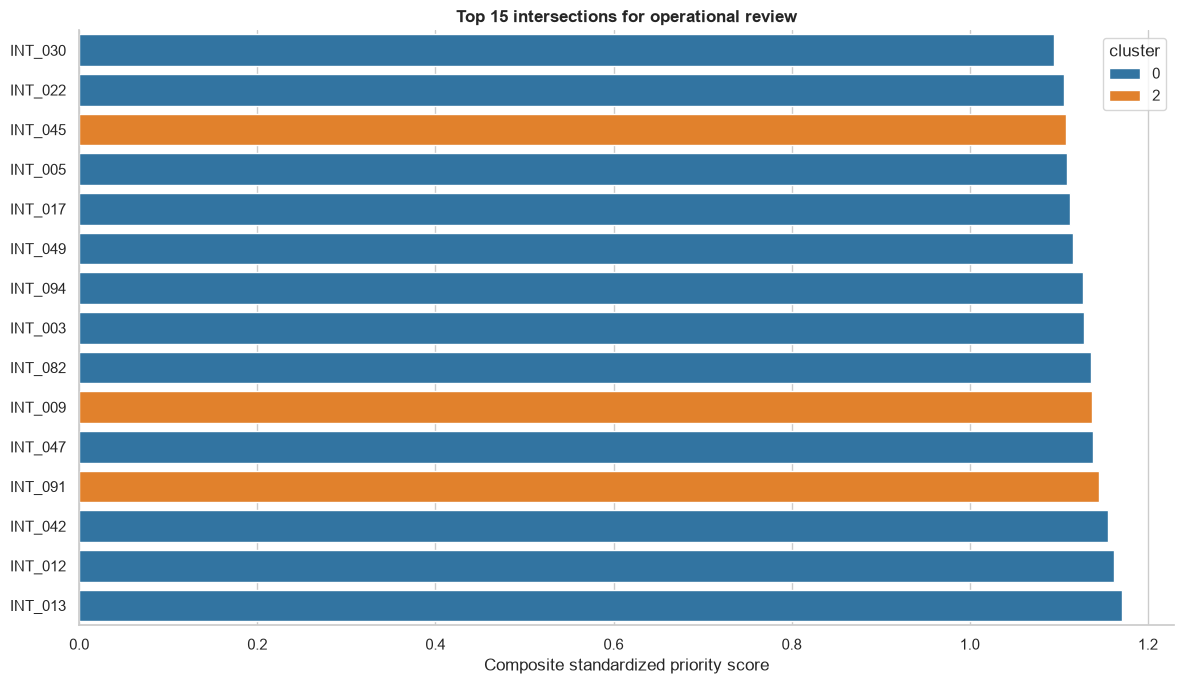

In [27]:
priority_features = ["congestion_mean", "queue_p95", "wait_mean", "severe_share", "emission_per_record", "fuel_waste_per_record"]
priority_z = StandardScaler().fit_transform(intersection_features[priority_features])
intersection_features["priority_score"] = priority_z.mean(axis=1)
hotspots = intersection_features.sort_values("priority_score", ascending=False).head(15)
display(hotspots[["intersection_id", "city_zone", "road_type", "cluster", "priority_score"] + priority_features])

plt.figure(figsize=(12, 7))
sea.barplot(data=hotspots.sort_values("priority_score"), y="intersection_id", x="priority_score", hue="cluster", dodge=False, palette="tab10")
plt.title("Top 15 intersections for operational review")
plt.xlabel("Composite standardized priority score"); plt.ylabel("")
plt.tight_layout(); plt.show()

In [28]:
# Generate a concise, data-driven action summary from the computed tables.
peak_row = heat.loc[heat.congestion.idxmax()]
worst_zone = zone_profile.index[0]
worst_zone_score = zone_profile.iloc[0].congestion_score
worst_weather = df.groupby("weather_condition").congestion_score.mean().idxmax()
accident_delta = context_effects.query("context == 'Accident' and metric == 'congestion_score'").relative_delta_pct.iloc[0]
top_cluster = int(intersection_features.groupby("cluster").priority_score.mean().idxmax())
top_ids = ", ".join(hotspots.intersection_id.head(5))

display(Markdown(f'''
### Recommended operational focus

1. **Staff the network around the highest-risk recurrent window:** {day_names[int(peak_row.day_of_week)]} at {int(peak_row.hour):02d}:00 has the highest mean congestion cell in the weekly heatmap.
2. **Prioritize zone-level diagnosis in {worst_zone}:** its mean congestion score is {worst_zone_score:.1f}, the highest zone average.
3. **Use weather-responsive plans for {worst_weather}:** this condition has the highest average congestion among observed weather categories.
4. **Audit incident playbooks:** records with an accident show a {accident_delta:+.1f}% descriptive difference in congestion score versus records without one.
5. **Investigate the highest-priority segment first:** cluster {top_cluster} has the highest mean screening score. Initial field-review candidates are {top_ids}.
6. **Track both mobility and sustainability:** pair delay/queue KPIs with CO₂ and fuel waste per 1,000 vehicles so throughput gains do not hide environmental costs.
'''))


### Recommended operational focus

1. **Staff the network around the highest-risk recurrent window:** Mon at 08:00 has the highest mean congestion cell in the weekly heatmap.
2. **Prioritize zone-level diagnosis in Downtown Core:** its mean congestion score is 52.5, the highest zone average.
3. **Use weather-responsive plans for Heavy Rain:** this condition has the highest average congestion among observed weather categories.
4. **Audit incident playbooks:** records with an accident show a +25.5% descriptive difference in congestion score versus records without one.
5. **Investigate the highest-priority segment first:** cluster 2 has the highest mean screening score. Initial field-review candidates are INT_013, INT_012, INT_042, INT_091, INT_047.
6. **Track both mobility and sustainability:** pair delay/queue KPIs with CO₂ and fuel waste per 1,000 vehicles so throughput gains do not hide environmental costs.


## 12. Limitations and next steps

- **Simulation realism:** the clean, complete panel and strong engineered relationships may overstate what production sensors deliver.
- **No causal claims:** incident, signal, weather, and infrastructure comparisons are confounded by time and location.
- **Repeated observations:** 204,000 rows do not equal 204,000 independent units; the panel contains 100 intersections over time.
- **Cluster stability:** rerun segmentation on another season and inspect whether assignments persist before operationalizing labels.
- **Deployment checks:** validate sensor calibration, missing-data behavior, latency, holiday definitions, timezone/DST handling, and intersection metadata.
- **Follow-on work:** the separate forecasting notebook evaluates 1–24 hour demand forecasts with leakage-safe time splits.